In [1]:
import pandas as pd # Used for Data Manipulation 
import numpy as np # used for Numerical Calculation
import seaborn as sns # Used for advanced data viszualation
import matplotlib.pyplot as plt # Used for data viszualation
import pickle # Used to save the model

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# Step 1: Load Data (Replace with actual dataset path)
data = pd.read_csv("IT_customer_churn.csv")

In [4]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [8]:
data.shape

(7043, 20)

In [9]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
# Step 2: Data Preprocessing
# Convert categorical columns to numeric using Label Encoding
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod','Churn']

for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])

In [12]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.5,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [13]:
# Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [14]:
# Convert MonthlyCharges to numeric
data['MonthlyCharges'] = pd.to_numeric(data['MonthlyCharges'], errors='coerce')

In [15]:
# Convert Tenure to numeric
data['tenure'] = pd.to_numeric(data['tenure'], errors='coerce')

In [16]:
# Splitting features and target
X = data.drop(columns=['Churn'])  
y = data['Churn']

In [17]:
X.dropna(inplace=True)

In [18]:
print(X.shape)
print(y.shape)

(7032, 19)
(7043,)


In [19]:
min_len = min(len(X), len(y))
X = X[:min_len]
y = y[:min_len]

In [20]:
print (X.shape)
print (y.shape)

(7032, 19)
(7032,)


In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

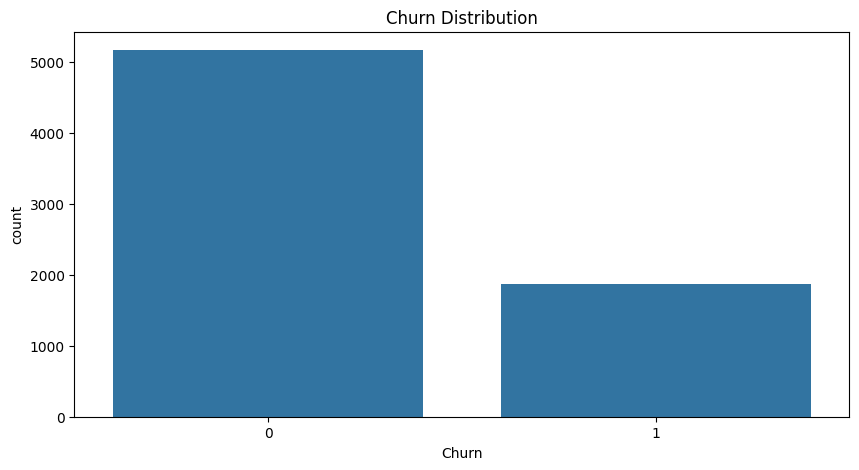

In [23]:
# Step 3: Exploratory Data Analysis (EDA) with Visualizations
plt.figure(figsize=(10,5))
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

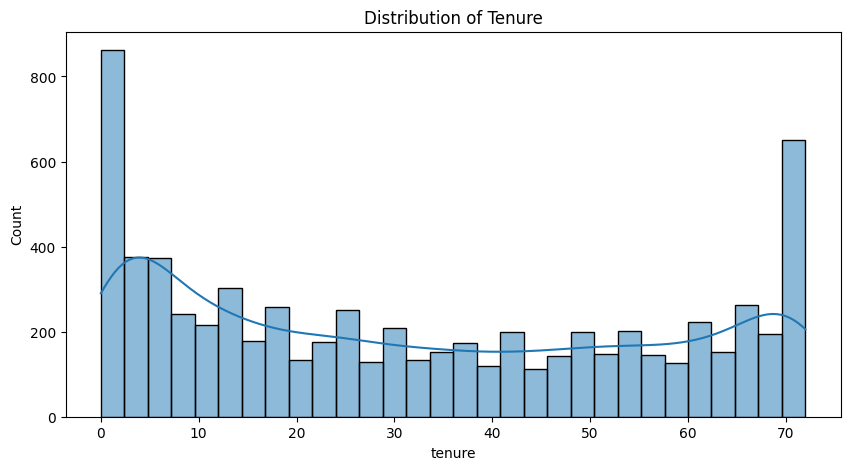

In [24]:
# Distribution of Numerical Features
plt.figure(figsize=(10, 5))
sns.histplot(data['tenure'], kde=True, bins=30)
plt.title("Distribution of Tenure")
plt.show()

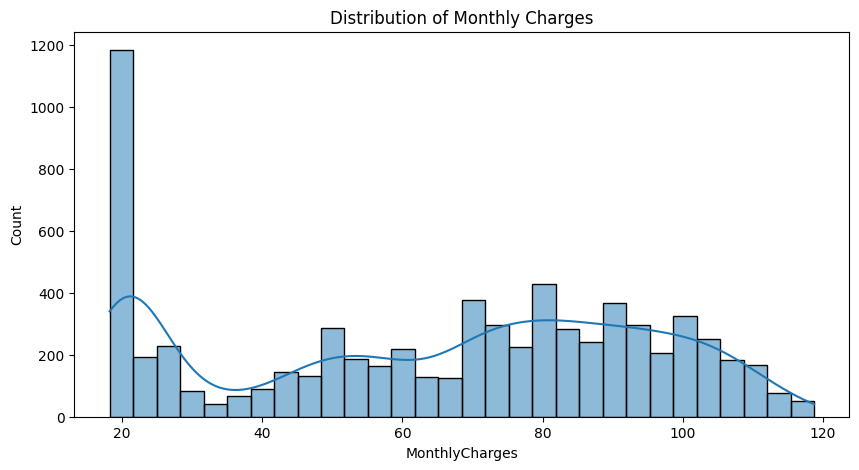

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(data['MonthlyCharges'], kde=True, bins=30)
plt.title("Distribution of Monthly Charges")
plt.show()

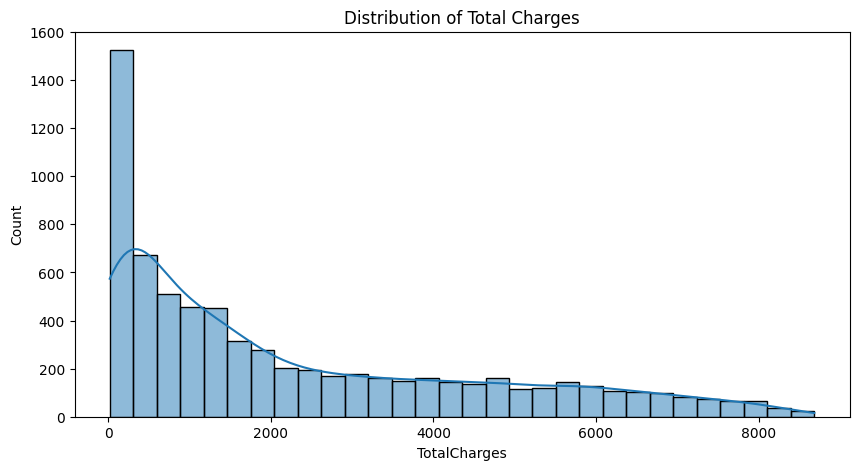

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(data['TotalCharges'], kde=True, bins=30)
plt.title("Distribution of Total Charges")
plt.show()

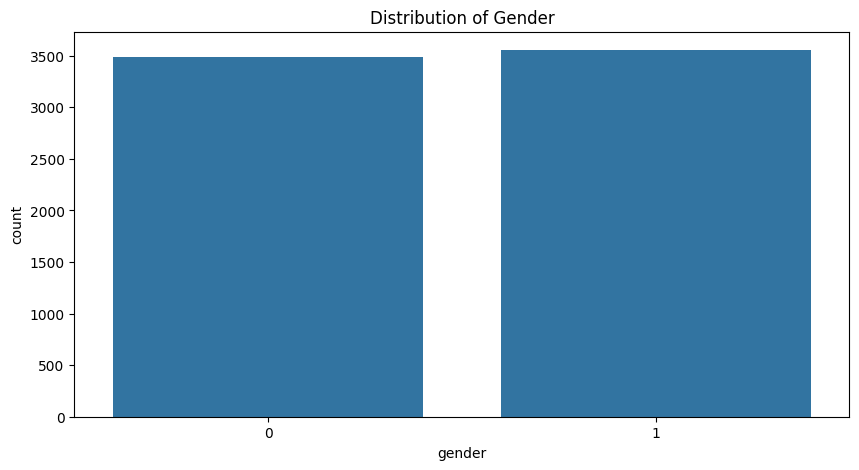

In [27]:
# Categorical Features Count Plots
plt.figure(figsize=(10, 5))
sns.countplot(x=data['gender'])
plt.title("Distribution of Gender")
plt.show()

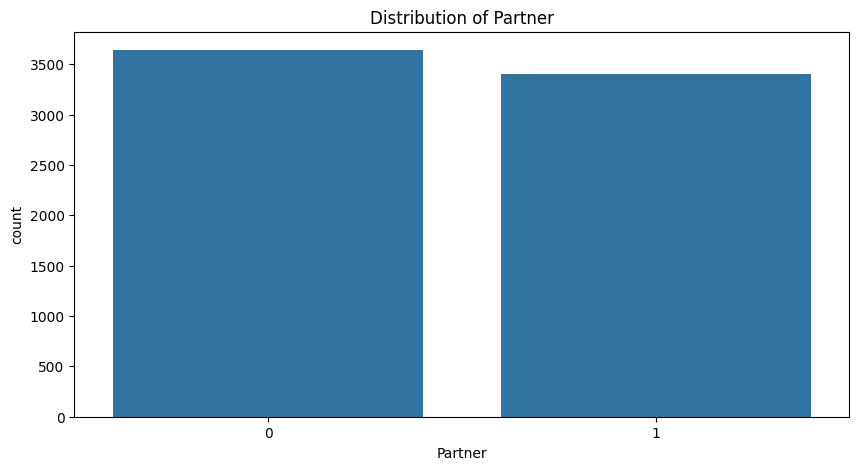

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['Partner'])
plt.title("Distribution of Partner")
plt.show()


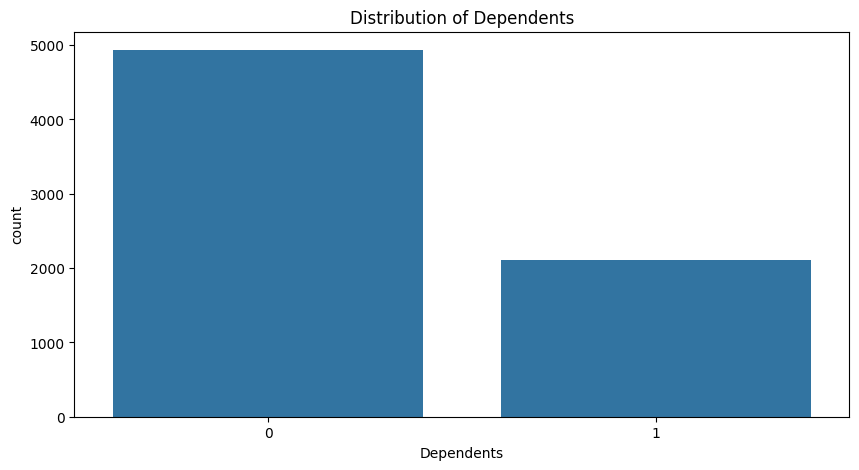

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['Dependents'])
plt.title("Distribution of Dependents")
plt.show()

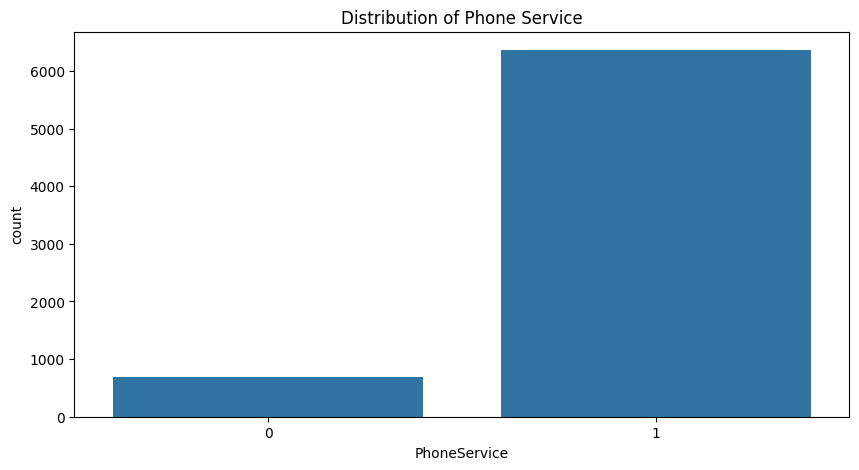

In [30]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['PhoneService'])
plt.title("Distribution of Phone Service")
plt.show()

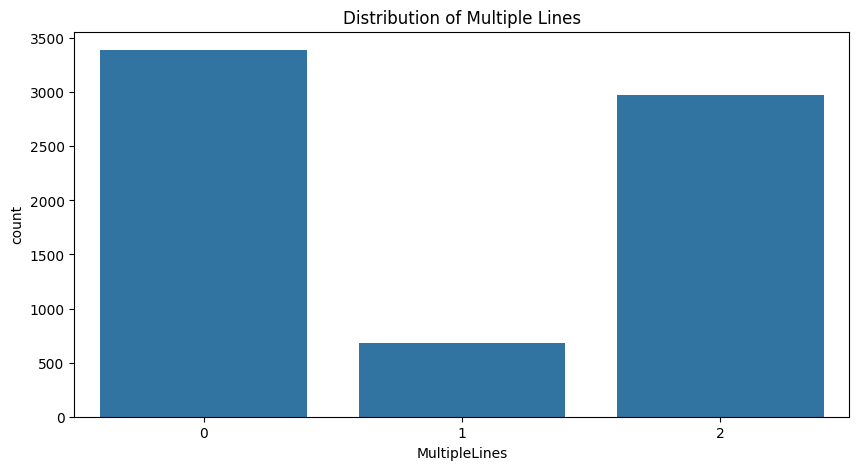

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['MultipleLines'])
plt.title("Distribution of Multiple Lines")
plt.show()

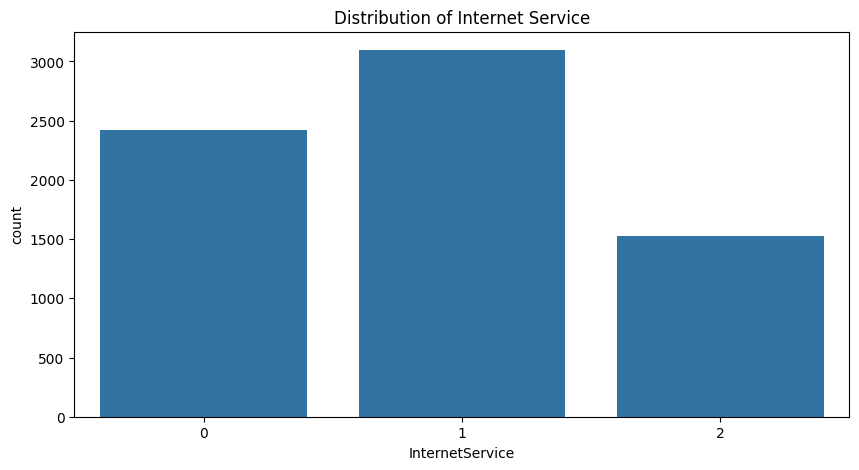

In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['InternetService'])
plt.title("Distribution of Internet Service")
plt.show()

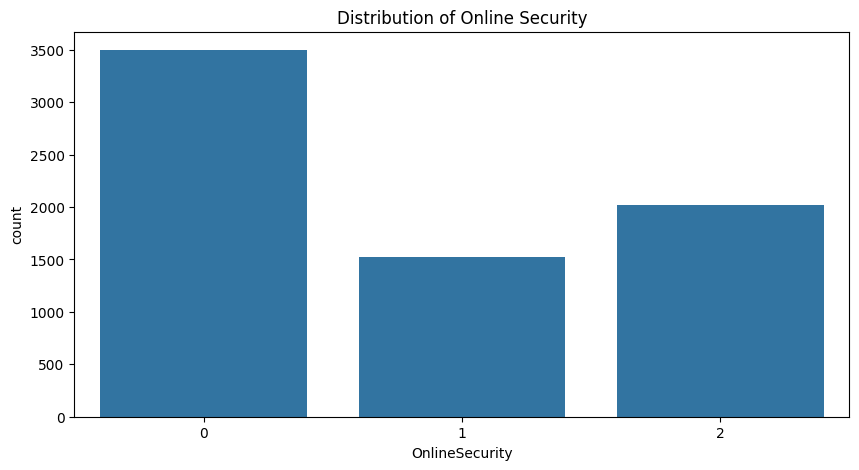

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['OnlineSecurity'])
plt.title("Distribution of Online Security")
plt.show()

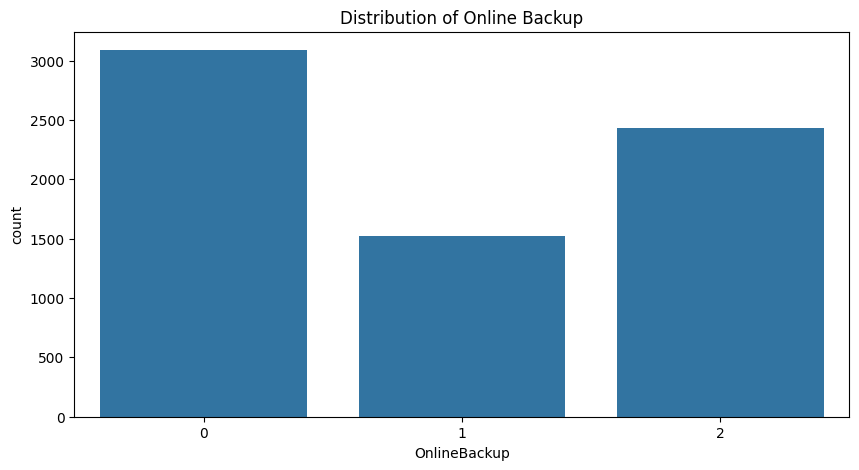

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['OnlineBackup'])
plt.title("Distribution of Online Backup")
plt.show()

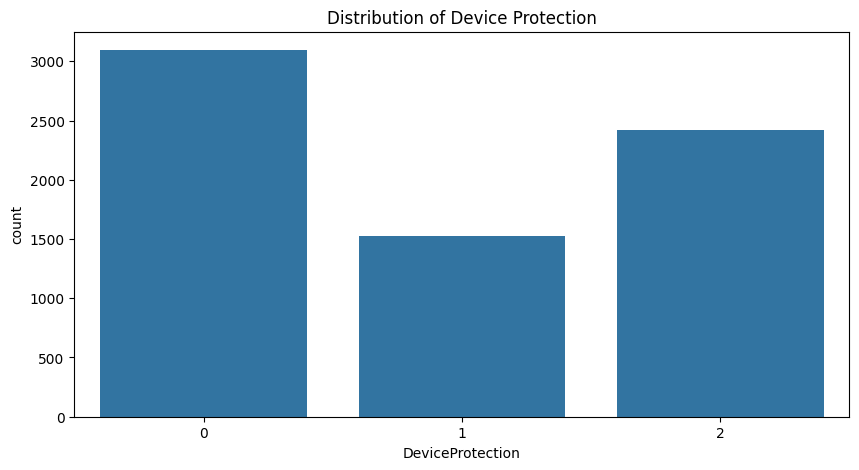

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['DeviceProtection'])
plt.title("Distribution of Device Protection")
plt.show()

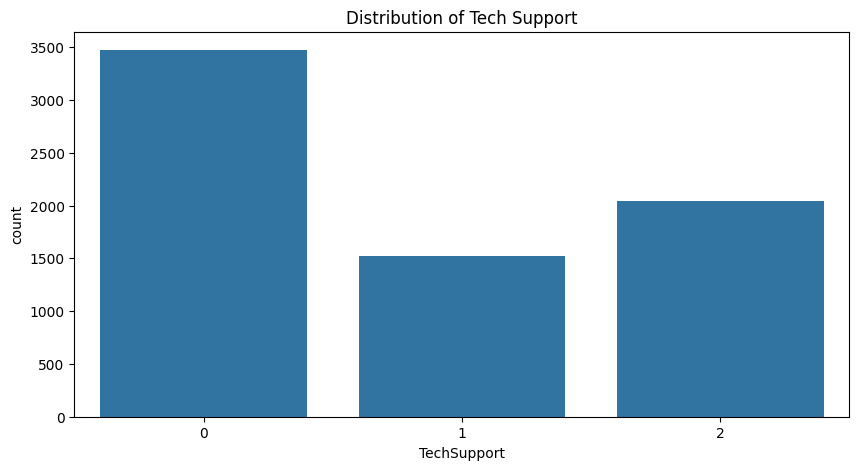

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['TechSupport'])
plt.title("Distribution of Tech Support")
plt.show()

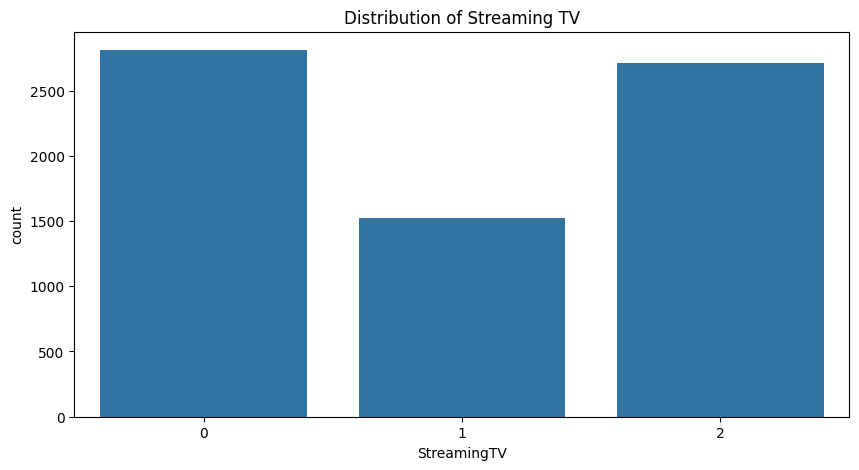

In [37]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['StreamingTV'])
plt.title("Distribution of Streaming TV")
plt.show()

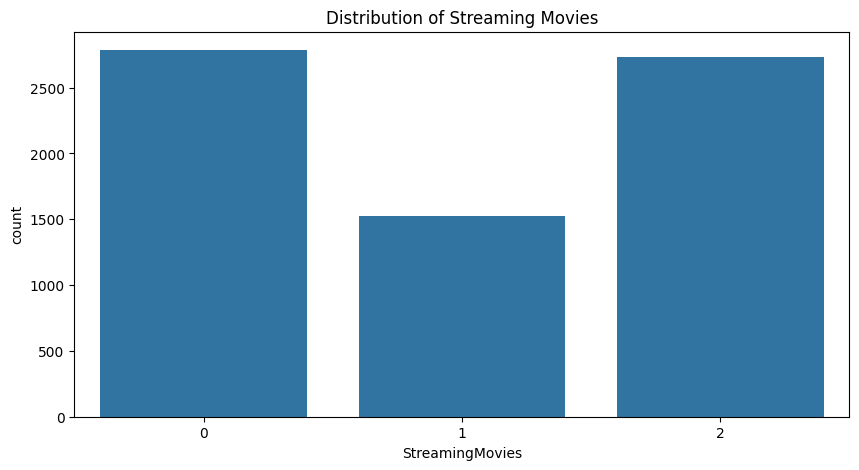

In [38]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['StreamingMovies'])
plt.title("Distribution of Streaming Movies")
plt.show()

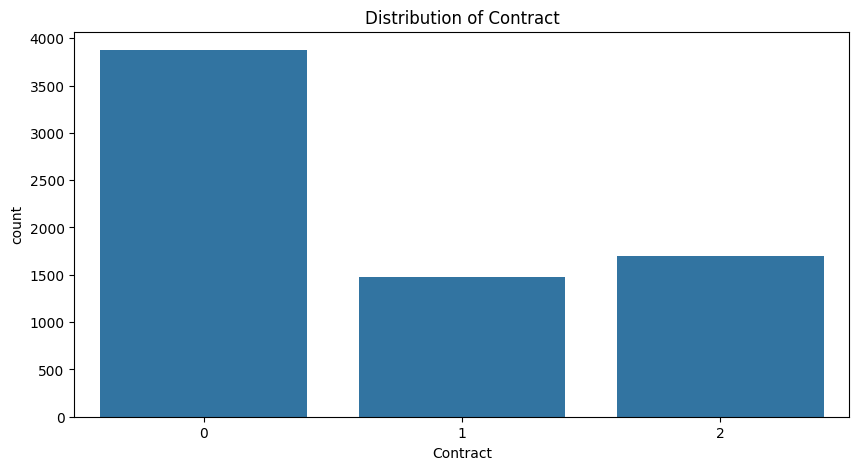

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['Contract'])
plt.title("Distribution of Contract")
plt.show()

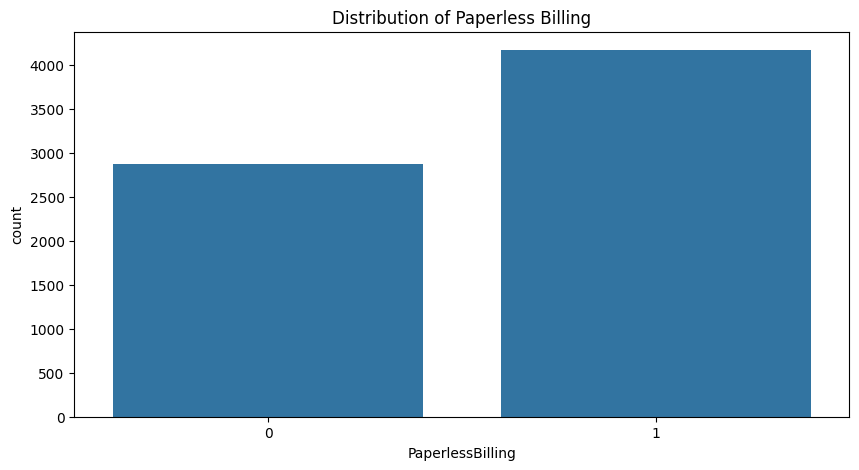

In [40]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['PaperlessBilling'])
plt.title("Distribution of Paperless Billing")
plt.show()

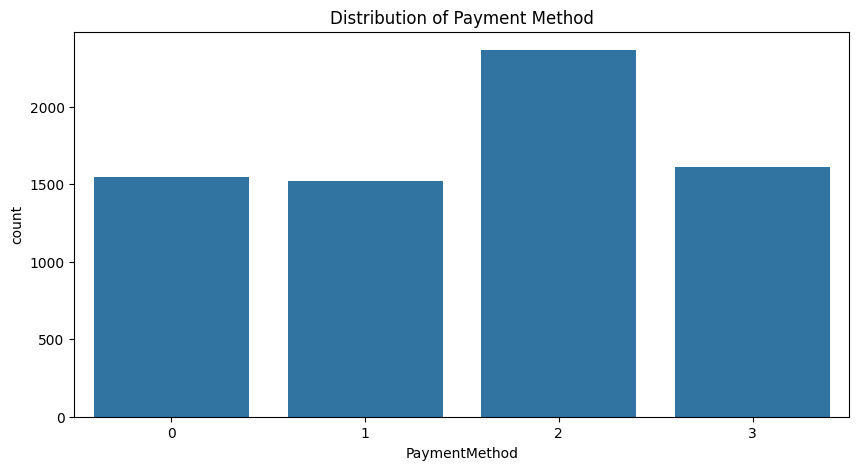

In [41]:
plt.figure(figsize=(10, 5))
sns.countplot(x=data['PaymentMethod'])
plt.title("Distribution of Payment Method")
plt.show()

In [42]:
from imblearn.over_sampling import SMOTE

In [43]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [44]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [45]:
y_resampled

0        0
1        0
2        1
3        0
4        1
        ..
10327    1
10328    1
10329    1
10330    1
10331    1
Name: Churn, Length: 10332, dtype: int64

In [46]:
%pip install lightgbm

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import sklearn.ensemble as ensemble


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [47]:
# ✅ Refined and Clean Model Definitions
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,  # ⛔️ Changed from 0.08 to 0.8 (0.08 is too small and causes underfitting)
    eval_metric='logloss',
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=64,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    class_weight='balanced',
    random_state=42
)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    eval_metric='Accuracy',
    verbose=100,
    random_state=42
)


In [48]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('cat', cat_model) # shorter name, cleaner logs
    ],
    voting='hard',         # soft = probability averaging (better for churn probs)
    n_jobs=-1              # utilize all CPU cores
)

ensemble.fit(X_train, y_train)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [49]:
# Predictions
from sklearn.ensemble import VotingClassifier
y_pred = ensemble.predict(X_test)       


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = ensemble.predict(X_test)

print("\n🎯 Ensemble Accuracy:\n", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5

🎯 Ensemble Accuracy:
 0.7895500725689405

📊 Confusion Matrix:
 [[904 137]
 [298 728]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81      1041
           1       0.84      0.71      0.77      1026

    accuracy                           0.79      2067
   macro avg       0.80      0.79      0.79      2067
weighted avg       0.80      0.79      0.79      2067



In [51]:
# Save the trained model
pickle.dump(ensemble,open( "churn_prediction_model.pkl",'wb'))